# CCDF of Regime Persistence Times

This notebook computes and plots the complementary cumulative distribution functions (CCDFs)
of regime persistence times $\tau_{AB}$ and $\tau_{BA}$ for the Holton-Mass model and the Emulator.

## Helper Functions

In [3]:
warnings.filterwarnings("ignore", category=UserWarning)

def normalize_transition_time(slope_value, delta, transition_real):
    normalized = 1 - np.exp(-np.abs((slope_value - transition_real)) / delta)
    return normalized

def total_variation_distance(p, q):
    p = np.array(p)
    q = np.array(q)
    return 0.5 * np.sum(np.abs(p - q))

# Code from Ira Shokar but slightly changed
def crps_score(predictions, actual):
    actual  = actual.unsqueeze(0)
    # First term: mean distance from observations to ensemble members
    mae     = torch.cdist(actual, predictions, 1).mean()
    # Second term: mean distance between ensemble members (properly normalized)
    ens_var = torch.cdist(predictions, predictions, 1).mean()
    
    return mae - 0.5 * ens_var

def calculate_transition_durations(u_series, upper, lower):
    # Ensure 1-D numeric array
    u_series = np.asarray(u_series).ravel()

    # Guard: empty input
    if u_series.size == 0:
        return []

    # Ensure bounds are scalars
    upper = float(np.squeeze(np.asarray(upper)))
    lower = float(np.squeeze(np.asarray(lower)))

    def zone(x):
        # squeeze to scalar, then cast
        x = np.squeeze(x)
        # If still not scalar, this is malformed input
        if np.size(x) != 1:
            raise ValueError("Each time-step must be scalar-like.")
        x = float(x)
        if np.isnan(x):
            return "nan"
        if x > upper:
            return "above"
        if x < lower:
            return "below"
        return "between"

    durations = []
    state = "idle"       # "idle", "A_to_b", "b_to_A"
    start_idx = None

    prev_z = zone(u_series[0])

    for i in range(1, len(u_series)):
        z = zone(u_series[i])

        # Any NaN cancels and resets
        if z == "nan":
            state = "idle"
            start_idx = None
            prev_z = z
            continue

        if state == "idle":
            # Start A→b when we leave ABOVE at this step
            if prev_z == "above" and z != "above":
                state = "A_to_b"
                start_idx = i  # index where we left > upper
                if z == "below":  # immediate completion
                    durations.append(0)
                    state = "idle"
                    start_idx = None

            # Start b→A when we leave BELOW at this step
            elif prev_z == "below" and z != "below":
                state = "b_to_A"
                start_idx = i  # index where we left < lower
                if z == "above":  # immediate completion
                    durations.append(0)
                    state = "idle"
                    start_idx = None

        elif state == "A_to_b":
            # If we go back > upper, cancel this transition
            if z == "above":
                state = "idle"
                start_idx = None
            # If we hit < lower, complete it
            elif z == "below":
                durations.append(i - start_idx)
                state = "idle"
                start_idx = None

        elif state == "b_to_A":
            # If we go back < lower, cancel this transition
            if z == "below":
                state = "idle"
                start_idx = None
            # If we hit > upper, complete it
            elif z == "above":
                durations.append(i - start_idx)
                state = "idle"
                start_idx = None

        prev_z = z

    return durations

def calculate_return_periods(y, u, l):
    """
    Calculate the return periods with user-defined upper and lower bounds.

    Args:
        y (np.array): The time series data.
        u (float): The upper bound for the transition.
        l (float): The lower bound for the transition.

    Returns:
        t_times (list): The list of return periods for transitions.
    """

    t_times = []
    s = None
    above_u = False
    below_l = False
    for i in range(1, len(y)):
        if y[i] < l:  
            if above_u and s is not None:
                t_times.append(i-s)
                s = None
                print(i)
            below_l = True
            above_u = False
        elif y[i] > u:  
            if below_l and s is not None:
                t_times.append(i - s)
                s = None 
                print(i)
            above_u = True
            below_l = False

        if below_l and s is None:
            s = i

        if above_u and s is None:
            s = i
    return t_times




def calculate_return_periods_separate(y, u, l):
    """
    Calculate return periods separately for A->B and B->A transitions.

    Args:
        y (np.array): The time series data.
        u (float): The upper bound (state A threshold).
        l (float): The lower bound (state B threshold).

    Returns:
        tau_AB (list): Persistence times in state A before reaching B.
        tau_BA (list): Persistence times in state B before reaching A.
    """
    tau_AB = []
    tau_BA = []
    s = None
    above_u = False
    below_l = False
    for i in range(1, len(y)):
        if y[i] < l:
            if above_u and s is not None:
                tau_AB.append(i - s)
                s = None
            below_l = True
            above_u = False
        elif y[i] > u:
            if below_l and s is not None:
                tau_BA.append(i - s)
                s = None
            above_u = True
            below_l = False

        if below_l and s is None:
            s = i
        if above_u and s is None:
            s = i
    return tau_AB, tau_BA

def KL_coefficient(real_data, pred_mean, delta, cycle, KL_by_dim_cycle):

    # Calculating KL divergence
    KL_real_data = real_data[:30000, 1, 63]
    KL_predictions = pred_mean[:30000]
    KL_row = []
    
    actual_hist, bin_edges = np.histogram(KL_real_data, bins=50, density=True)
    pred_hist, _ = np.histogram(pred_mean, bins=bin_edges, density=True)

    epsilon = 1e-10
    actual_hist += epsilon
    pred_hist += epsilon

    # Calculate KL divergence between the two histograms
    KL = np.sum(actual_hist * np.log(actual_hist / pred_hist))

    norm_KL = normalize_transition_time(KL, 1, 0)
    print(f"Normalized KL divergence for delta {delta}, cycle {cycle}: {norm_KL:.6f}")
    KL_by_dim_cycle[delta][cycle].append(norm_KL)

    return KL_real_data, KL_predictions, norm_KL

def Slope_fit(pred_durations, slope_real, epoch):
    # === PREDICTIONS CCDF AND FIT ===
    if len(pred_durations) > 0 and len(np.unique(pred_durations)) > 1:
        pred_data_sorted = np.sort(pred_durations)
        ccdf_pred = 1 - np.arange(1, len(pred_data_sorted) + 1) / len(pred_data_sorted)

        valid_indices_pred = ccdf_pred > 0
        x_fit_pred = pred_data_sorted[valid_indices_pred]
        y_fit_pred = np.log(ccdf_pred[valid_indices_pred])

        slope_pred, intercept_pred, *_ = linregress(x_fit_pred, y_fit_pred)
        slope_diff_normalized = normalize_transition_time(slope_pred, 0.005, slope_real)
        return slope_diff_normalized

    else:
        print("No transitions detected in predictions for CCDF slope evaluation.")

def Mean_and_std_of_predictions(pred_durations, real_durations, delta, cycle, transitions_by_dim_cycle, transitions_normalized_by_dim_cycle, transitions_normalized_std_by_dim_cycle):
    transition_mean = np.mean(pred_durations)
    transition_std = np.std(pred_durations)

    transition_mean_diff = abs(transition_mean - np.mean(real_durations))
    transition_std_diff = abs(transition_std - np.std(real_durations))

    transition_mean_diff_normalized = normalize_transition_time(transition_mean_diff, 1000, np.mean(real_durations))
    transition_std_diff_normalized = normalize_transition_time(transition_std_diff, 1000, np.std(real_durations))

    if transition_std_diff_normalized == 0:
        transition_std_diff_normalized = 1

    transitions_by_dim_cycle[delta][cycle].append(transition_mean_diff)
    transitions_normalized_by_dim_cycle[delta][cycle].append(transition_mean_diff_normalized)
    transitions_normalized_std_by_dim_cycle[delta][cycle].append(transition_std_diff_normalized)

    return transition_mean_diff_normalized, transition_std_diff_normalized

# KL Annealing
def frange_cycle_linear(start, stop, n_epoch, n_cycle=4, ratio=0.5):
    L = np.ones(n_epoch)
    period = n_epoch/n_cycle
    step = (stop-start)/(period*ratio) # linear schedule

    for c in range(n_cycle):

        v , i = start , 0
        while v <=stop and (int(i+c*period) < n_epoch):
            L[int(i+c*period)] = v
            v += step
            i += 1
    return L


def model_restore(model_path, model):
    if os.path.exists(model_path):
        print(f"Loading model from {model_path}")
        model.load_state_dict(torch.load(model_path))

def inference(model, psi, tst, vr, v, nv, ld):
    """
    Perform inference using the trained model.

    Args:
        model (nn.Module): The trained model.
        psi (np.array): Input data for inference.
        tst (int): Number of time steps.
        vr (dict): Variable ranges for the input data.
        v (int): Index of the variable to use for inference.
        nv (int): Number of variables.
        ld (int): Latent dimension of the model.
    
    Returns:
        p (np.array): Predictions made by the model.
    """
    s, e = vr[v][0], vr[v][1]+1
    init_c = torch.reshape(torch.tensor(psi[0,:]), [1, 75])
    p = np.zeros ([tst, 75])

    for k in range (0, tst):

        with torch.inference_mode():
            model.eval()

            with autocast(device_type='cuda'):

                if (k ==0):

                    init_c = init_c.float().cuda(non_blocking=True)
                    y, _, _ = (model(init_c, init_c[:,:50]))
                    y = y.detach().cpu().numpy()
                    p[k,:] = y
                    init_c = torch.tensor(y[:, s:e])

                else:

                    init_c = torch.reshape(torch.tensor(p[k-1,:]),[1,75]).float().cuda(non_blocking=True)
                    y, _, _ = (model(init_c,init_c[:,:50]))
                    y = y.detach().cpu().numpy()
                    p[k,:] = y
                    init_c = torch.tensor(y[:, s:e])
    
    return p

def euclidean_distance_for_predictions(metrics):
    sum = 0
    for metric in metrics:
        sum += metric ** 2
    distance = np.sqrt(sum)
    return distance

def save_best_cycle_epoch(models, delta, cycle, epoch, 
                          exp_fit_normalized_by_dim_cycle, 
                          KL_by_dim_cycle, duration_diff_by_dim_cycle, 
                          best_models_saved, best_models, master_folder):
    
    best_model = None
    best_index = -1
    best_distance = float('inf')

    for i in range(len(models)):  # models contains each epoch's model in the current cycle

        metrics = [exp_fit_normalized_by_dim_cycle[delta][cycle][i],
                   KL_by_dim_cycle[delta][cycle][i], 
                   duration_diff_by_dim_cycle[delta][cycle][i]]
        
        distance = euclidean_distance_for_predictions(metrics)
        if distance < best_distance:
            best_distance = distance
            shutil.copyfile(models[i], f"{master_folder}/best_model_combined_distance_at_cycle_{cycle}_and_checkpoint_{epoch}.pth")
            print(f"New best model saved with distance {distance:.4f} at epoch {i+1}")
            best_index = i
            best_model = models[i]

    if best_index != -1:
        best_models_saved.append(best_model)
        best_models.append((cycle, best_index))

def save_best_epoch(best_models, best_models_saved, exp_fit_normalized_by_dim_cycle,
                    KL_by_dim_cycle, duration_diff_by_dim_cycle, delta, master_folder):
    
    print("Selecting the best model based on combined distance...")

    # Ensure best_models is not empty
    if not best_models:
        print("No best models found.")
        return
    
    # After all cycles - final best model selection
    best_model = None
    where_model = (-1, -1)
    best_model_distance = float('inf')

    print(f"Number of best models saved: {len(best_models)}")
    for idx, (cycle_num, epoch_idx) in enumerate(best_models):

        metrics = [exp_fit_normalized_by_dim_cycle[delta][cycle_num][epoch_idx], 
                   KL_by_dim_cycle[delta][cycle_num][epoch_idx], 
                   duration_diff_by_dim_cycle[delta][cycle_num][epoch_idx]]
        
        distance = euclidean_distance_for_predictions(metrics)        
        print(f"Distance for model from cycle {cycle_num+1}, epoch {epoch_idx+1}: {distance:.4f}")
        print(f"Current best distance: {best_model_distance:.4f}")
        
        if distance < best_model_distance:
            best_model_distance = distance
            best_model = best_models_saved[idx]
            where_model = (cycle_num, epoch_idx)

    # Save the best model  
    i,n = where_model
    cycle = i
    epoch = n

    if cycle == -1:
        print("No best model found.")
    else:
        shutil.copyfile(best_model, f"{master_folder}/best_model_combined_distance_with_cycle_{cycle+1}_and_epoch_{epoch+1}.pth")
        print(f"Best model saved with cycle {cycle+1} and epoch {epoch+1}.")




## Compute Return Periods

3283
7060
7159
7902
8483
9978
11316
12720
13441
13761
13946
15416
15859
15992
16683
16974
17816
18551
19126
19808
20108
20807
21492
23897
24420
25080
25412
25577
25651
26200
26777
27545
28190
29467
35259
37220
37294
38369
39205
41315
41864
43093
43884
44437
44585
46296
50104
50639
51794
52083
54922
55938
56996
59035
60564
60807
61519
61589
61643
61954
62752
62837
62953
64017
64355
67294
67350
67445
67957
68687
69034
73053
74590
74859
75504
76361
77149
78380
78669
79021
80060
80280
80551
82511
82556
82761
85004
86021
86360
86863
87517
88008
91264
92135
93110
93156
93855
94084
95215
96133
97004
98142
98222
98232
98796
99400
99685
100621
101217
101991
102738
103404
103939
107578
107799
108476
108520
109957
110700
111064
111148
111723
111804
113795
114390
115863
116854
120434
120505
122739
123733
123810
123921
124080
124203
124995
125129
125319
126540
127050
128308
129822
130283
131189
132222
132400
133149
133212
133261
134252
134817
135267
135383
135839
135881
137048
137301
139299
140938


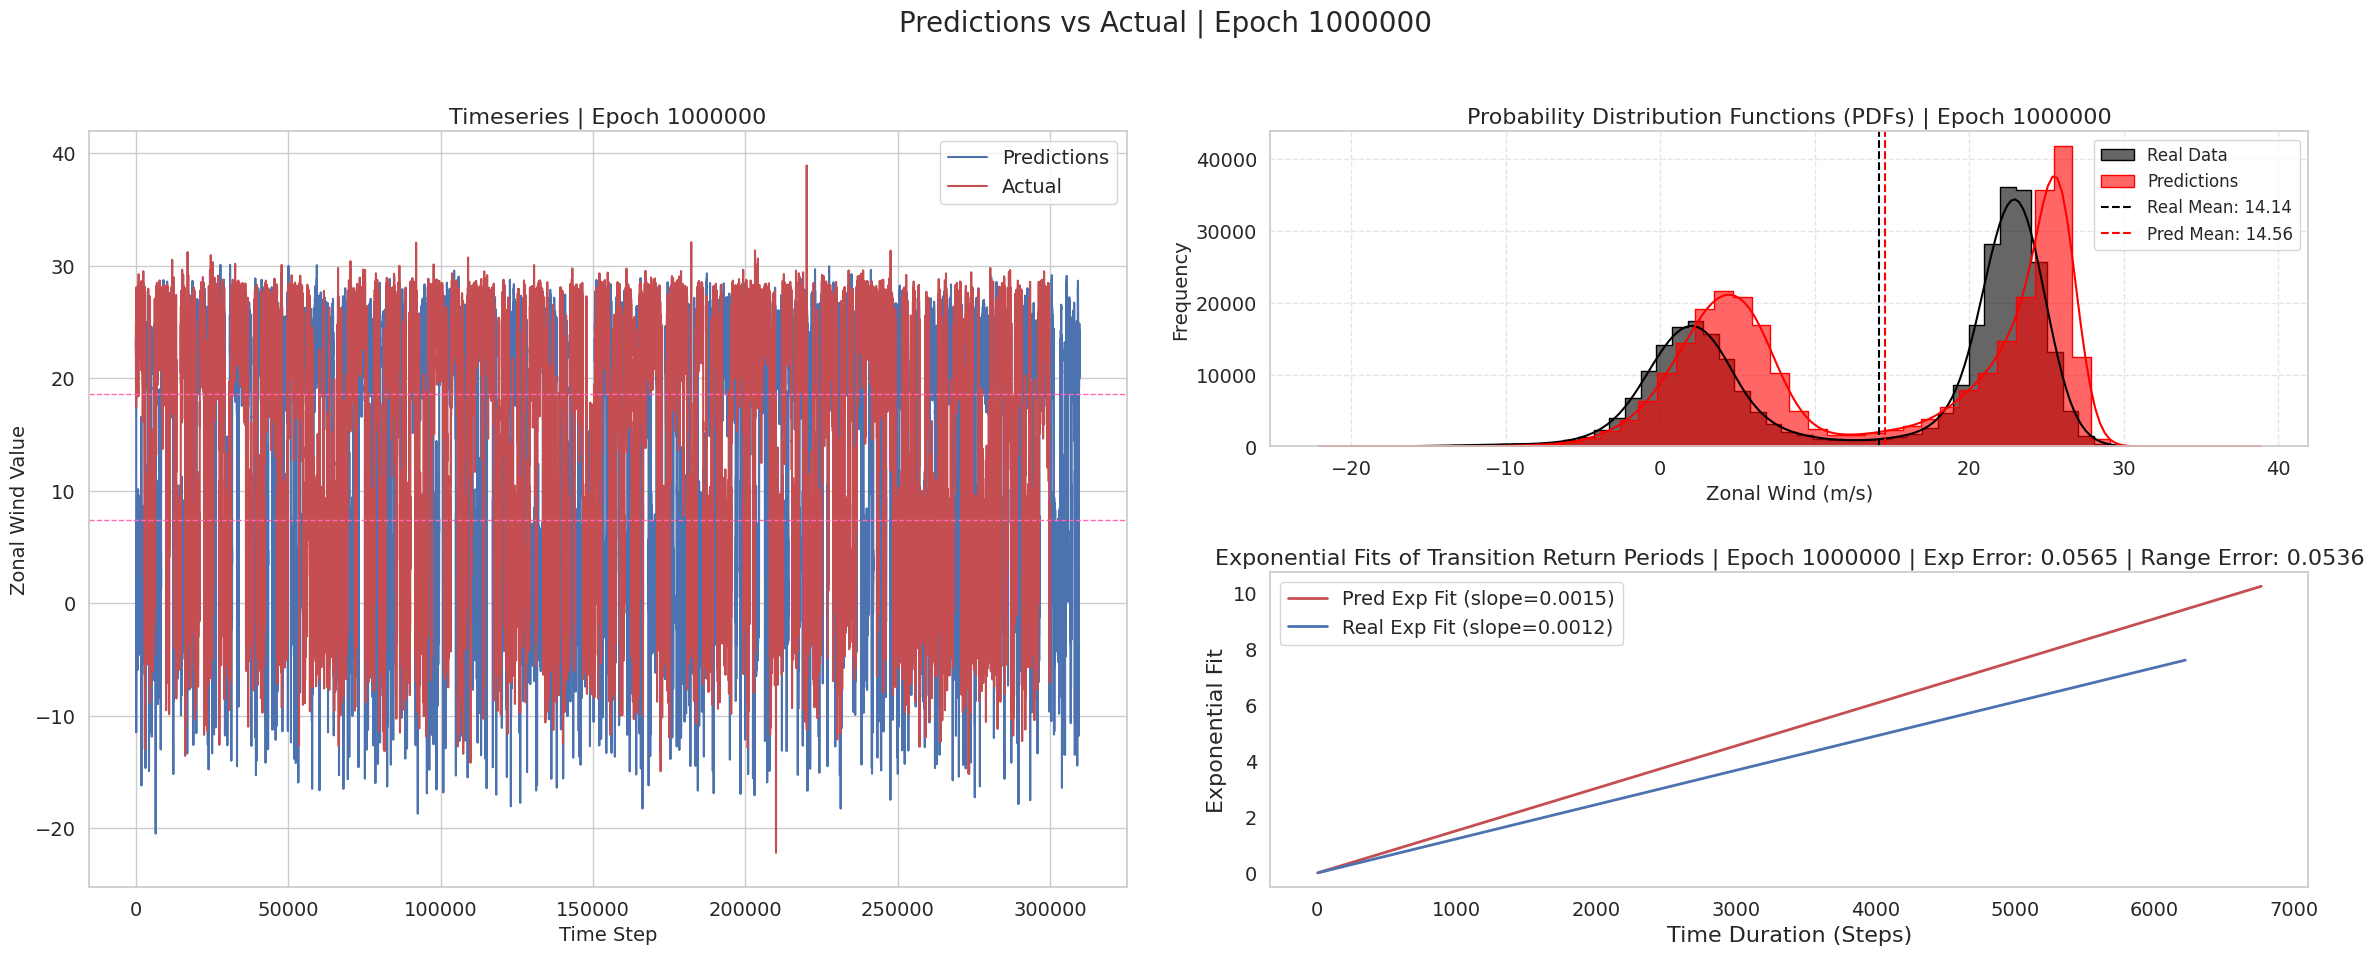

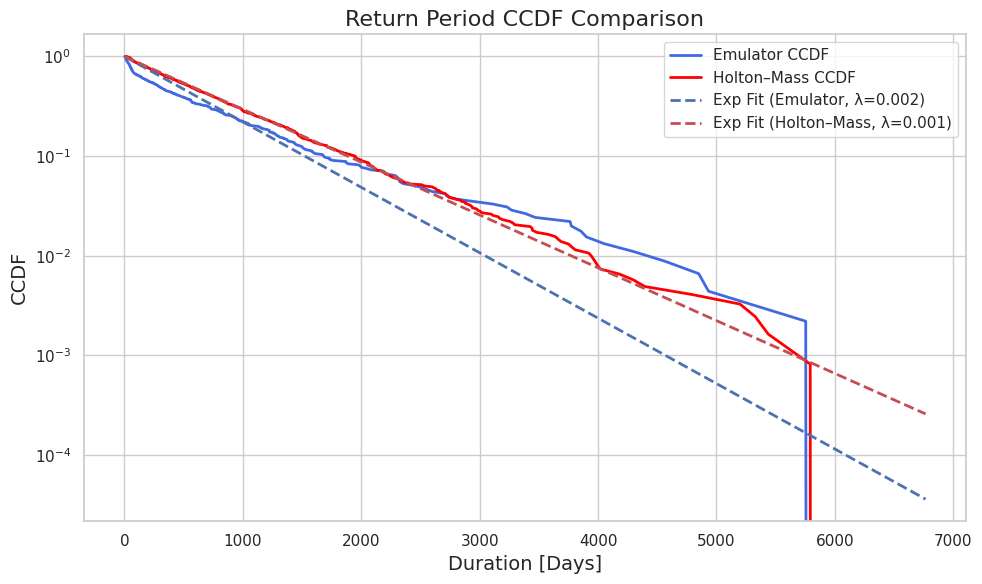

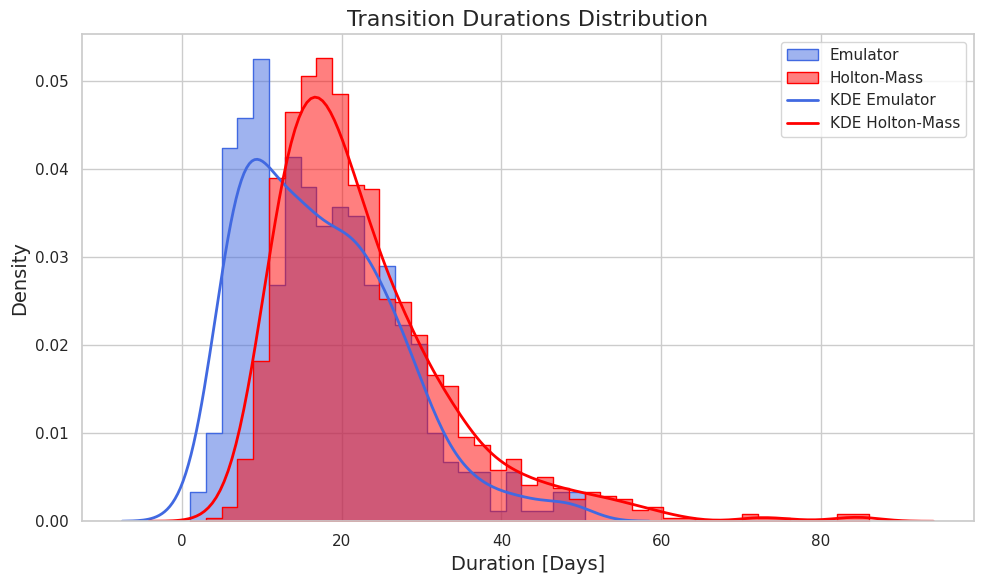

In [22]:
import os
import numpy as np
import torch
import torch.optim as optim
from torch.cuda.amp import autocast
from scipy.stats import expon
from scipy.stats import linregress
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

plt.rcParams.update({
    "font.size": 16,          # base font size
    "axes.titlesize": 18,     # title
    "axes.labelsize": 16,     # x/y labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})


# =========================
# Helper: shared bin edges
# =========================
def shared_bin_edges(a, b, bins=20, method=None, data_range=None):
    """
    Compute a single set of histogram bin EDGES from pooled data a+b.
    Use this to ensure both histograms are plotted on identical bins.
    - bins: int or explicit sequence of edges
    - method: one of numpy's rules: 'fd', 'doane', 'scott', 'rice', 'sturges', 'sqrt'
    - data_range: (min, max); if None, computed from pooled data
    """
    a = np.asarray(a)
    b = np.asarray(b)
    data = np.concatenate([a, b])

    if data_range is None:
        data_min, data_max = np.nanmin(data), np.nanmax(data)
        # Prevent degenerate case when all values are equal
        if data_min == data_max:
            eps = 1e-9 if data_min == 0 else 1e-9 * abs(data_min)
            data_range = (data_min - eps, data_max + eps)

    if isinstance(bins, (list, tuple, np.ndarray)):
        edges = np.asarray(bins, dtype=float)
    else:
        rule = method if method is not None else bins
        edges = np.histogram_bin_edges(data, bins=rule, range=data_range)

    return edges

# =========================
# Your existing parameters
# =========================
from sklearn.metrics import mean_squared_error  # if used elsewhere

time_step = 1_000_000
real_data = np.load(r'/home/danyul/ssw/stochastic_trajectories.npy')
preds = np.load(r'/home/danyul/ssw/predictions.npy')
level = 63
upper_bound     = 53.8 / 2.8935
lower_bound     = 7.41
real_data_1d    = real_data[:time_step, 1, level]

# =========================
# Real durations + CCDF
# =========================
real_durations      = calculate_return_periods(real_data_1d, upper_bound, lower_bound)
real_data_sorted    = np.sort(real_durations)
transition_real     = np.mean(real_data_sorted)
actual_hist, bin_edges = np.histogram(real_data[:, 1, level], bins=50, density=True)
print(f"Reference Real Data average_transition_time: {transition_real}")

# CCDF slope for real data
ccdf_real           = 1 - np.arange(1, len(real_data_sorted) + 1) / len(real_data_sorted)
valid_indices_real  = ccdf_real > 0
x_fit_real          = real_data_sorted[valid_indices_real]
y_fit_real          = np.log(ccdf_real[valid_indices_real])
slope_real, intercept_real, *_ = linregress(x_fit_real, y_fit_real)
print(f"Reference Real Data CCDF Slope: {slope_real}")

# Exponential fit for real data
x_line_real = np.linspace(float(np.min(real_data_sorted)), float(np.max(real_data_sorted)), 100)
exponential_fit_real = 1/np.mean(real_data_sorted)
y_values_real = exponential_fit_real*x_line_real

actual_values = psi[:time_step, :] * std_psi[:, :] + mean_psi[:, :]  # assumes psi
predictions_1d = preds[:time_step, level]

pred_durations = calculate_return_periods(predictions_1d, upper_bound, lower_bound)
# Separate return periods by direction
real_tau_AB, real_tau_BA = calculate_return_periods_separate(real_data_1d, upper_bound, lower_bound)
pred_tau_AB, pred_tau_BA = calculate_return_periods_separate(predictions_1d, upper_bound, lower_bound)
print(f"Real tau_AB: {len(real_tau_AB)}, tau_BA: {len(real_tau_BA)}")
print(f"Pred tau_AB: {len(pred_tau_AB)}, tau_BA: {len(pred_tau_BA)}")
print(f"Reference Prediction Data average_transition_time: {np.mean(pred_durations)}")
print(f"==>> pred_durations: {pred_durations}")
print(f"==>> real_durations: {real_durations}")

# =========================
# Compare exponential fits
# =========================
max_pred = np.max(pred_durations)
min_pred = np.min(pred_durations)
difference = abs(max_pred - min_pred)
duration_diff_normalized = normalize_transition_time(  # assumes function
    difference, 10000, abs(np.max(real_durations) - np.min(real_durations))
)

x_line_pred = np.linspace(float(np.min(pred_durations)), float(np.max(pred_durations)), 100)
exponential_fit_pred = 1/np.mean(pred_durations)
exp_fit_normalized = normalize_transition_time(       # assumes function
    exponential_fit_pred, 0.005, exponential_fit_real
)
y_values_pred = exponential_fit_pred * x_line_pred
epoch = 1_000_000
master_folder = r'/home/danyul/ssw'

all_plot_inference(  # assumes function
    actual_values[:time_step, level],
    predictions_1d[:time_step],
    x_line_pred, y_values_pred,
    x_line_real, y_values_real,
    exponential_fit_pred, exponential_fit_real,
    exp_fit_normalized, duration_diff_normalized, epoch, master_folder
)

# =========================
# Plot: Return Periods
# =========================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

#Sort durations
pred_sorted = np.sort(pred_durations)
real_sorted = np.sort(real_durations)

#Compute CCDF values
ccdf_pred = 1 - np.arange(1, len(pred_sorted)+1) / len(pred_sorted)
ccdf_real = 1 - np.arange(1, len(real_sorted)+1) / len(real_sorted)

#Plot CCDF
plt.plot(pred_sorted, ccdf_pred, color="royalblue",
         label="Emulator CCDF", linewidth=2)
plt.plot(real_sorted, ccdf_real, color="red",
         label="Holton–Mass CCDF", linewidth=2)

#Exponential reference lines
x_vals_rp = np.linspace(0, max(real_sorted.max(), pred_sorted.max()), 400)

lambda_pred = 1 / np.mean(pred_durations)
lambda_real = 1 / np.mean(real_durations)

plt.plot(x_vals_rp, np.exp(-lambda_pred * x_vals_rp),
         "b--", linewidth=2,
         label=f"Exp Fit (Emulator, λ={lambda_pred:.3f})")

plt.plot(x_vals_rp, np.exp(-lambda_real * x_vals_rp),
         "r--", linewidth=2,
         label=f"Exp Fit (Holton–Mass, λ={lambda_real:.3f})")

plt.yscale("log")        
plt.xlabel("Duration [Days]", fontsize=14)
plt.ylabel("CCDF", fontsize=14)
plt.title("Return Period CCDF Comparison", fontsize=16)
plt.legend()
plt.tight_layout()
plt.savefig("CCDF_return_periods.png",
            dpi=300, bbox_inches="tight")
plt.show()


# =========================
# Plot: Transition Durations
# =========================
transition_durations_pred = calculate_transition_durations(predictions_1d, upper_bound, lower_bound)
transition_durations_real = calculate_transition_durations(real_data_1d, upper_bound, lower_bound)

fig, ax = plt.subplots(figsize=(10, 6))

# Shared bin edges for transition duration histograms (pooled real + pred)
td_edges = shared_bin_edges(transition_durations_pred, transition_durations_real, method='fd')
# Alternatively: td_edges = shared_bin_edges(transition_durations_pred, transition_durations_real, bins=20)

# Histograms with identical bins and density for comparability
sns.histplot(transition_durations_pred, color="royalblue", label="Emulator",
             alpha=0.5, bins=td_edges, stat="density", element="step")
sns.histplot(transition_durations_real, color="red", label="Holton-Mass",
             alpha=0.5, bins=td_edges, stat="density", element="step")

sns.kdeplot(x=transition_durations_pred, ax=ax, color="royalblue",
            lw=2, fill=False, bw_adjust=1.0, common_norm=False, label="KDE Emulator")
sns.kdeplot(x=transition_durations_real, ax=ax, color="red",
            lw=2, fill=False, bw_adjust=1.0, common_norm=False, label="KDE Holton-Mass")

# Optional: KDE overlays (comment out if you want pure histogram rigor)
# sns.kdeplot(transition_durations_pred, color="royalblue", linewidth=1, label="KDE Pred", alpha=0.7)
# sns.kdeplot(transition_durations_real, color="orange", linewidth=1, label="KDE Real", alpha=0.7)

plt.title("Transition Durations Distribution", fontsize=16)
plt.xlabel("Duration [Days]", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig("transitions.png",
            dpi=300, bbox_inches="tight")
plt.show()


## CCDF Plot with Bootstrap Confidence Intervals

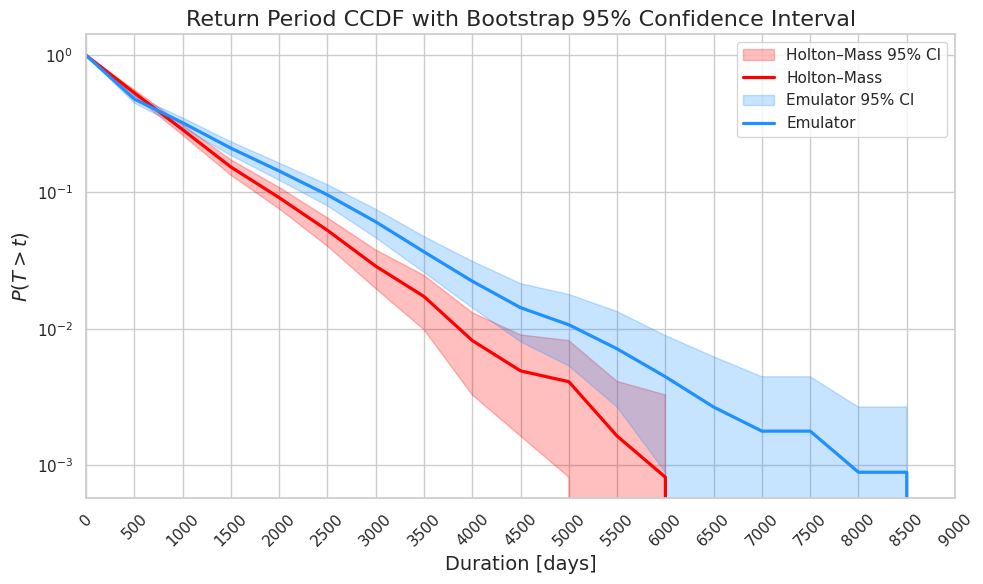

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Helper: empirical CCDF at fixed bins
# ============================================================

def empirical_ccdf(sorted_sample, bins):
    """
    Compute empirical CCDF P(T > t) evaluated at fixed bins.
    """
    n = len(sorted_sample)
    idx = np.searchsorted(sorted_sample, bins, side="right")
    return 1.0 - idx / n


# ============================================================
# Bootstrap CCDF (no smoothing, no monotonic fixes)
# ============================================================

def bootstrap_ccdf(durations, bins, n_bootstrap=1000, seed=42):
    """
    Compute bootstrap CCDF with percentile confidence bands.
    """
    durations = np.asarray(durations)
    n = len(durations)
    sorted_original = np.sort(durations)

    rng = np.random.default_rng(seed)
    boot = np.empty((n_bootstrap, len(bins)))

    for b in range(n_bootstrap):
        sample = rng.choice(sorted_original, size=n, replace=True)
        boot[b, :] = empirical_ccdf(np.sort(sample), bins)

    low = np.percentile(boot, 2.5, axis=0)
    med = np.percentile(boot, 50.0, axis=0)
    high = np.percentile(boot, 97.5, axis=0)

    return med, low, high


# ============================================================
# MAIN CCDF COMPUTATION - SEPARATE tau_AB and tau_BA
# ============================================================

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True, sharey=True)

# Synchronized x-axis: use global max across both directions
global_max = max(np.max(real_tau_AB), np.max(pred_tau_AB), np.max(real_tau_BA), np.max(pred_tau_BA))
bins = np.arange(0, global_max + 500, 500)

for ax, real_dur, pred_dur, label in [
    (axes[0], real_tau_AB, pred_tau_AB, r"$\tau_{AB}$ (Persistence in A)"),
    (axes[1], real_tau_BA, pred_tau_BA, r"$\tau_{BA}$ (Persistence in B)"),
]:

    hm_med, hm_low, hm_high = bootstrap_ccdf(real_dur, bins, n_bootstrap=1000, seed=123)
    em_med, em_low, em_high = bootstrap_ccdf(pred_dur, bins, n_bootstrap=1000, seed=456)

    # Holton-Mass = RED
    ax.fill_between(bins, hm_low, hm_high, color="red", alpha=0.25, label="Holton-Mass 95% CI")
    ax.plot(bins, hm_med, color="red", linewidth=2.3, label="Holton-Mass")

    # Emulator = DODGER BLUE
    ax.fill_between(bins, em_low, em_high, color="#1e90ff", alpha=0.25, label="Emulator 95% CI")
    ax.plot(bins, em_med, color="#1e90ff", linewidth=2.3, label="Emulator")

    ax.set_yscale("log")
    # x-label set below for bottom panel only
    ax.set_title(label, fontsize=16)
    ax.legend(fontsize=11)

axes[0].set_ylabel(r"$\it{P}(T > t)$", fontsize=14)
axes[1].set_ylabel(r"$\it{P}(T > t)$", fontsize=14)
axes[1].set_xlabel("Duration [days]", fontsize=14)

plt.suptitle("Return Period CCDFs with Bootstrap 95% Confidence Intervals", fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig("/home/danyul/CCDF_return_periods_separate_500day_bins.png",
            dpi=300, bbox_inches="tight")
plt.show()